# **Project 1: Fast Food Marketing Campaign A/B Test**

## Scenario
A fast-food chain plans to add a new item to its menu. However, they are still undecided between three possible marketing campaigns for promoting the new product. In order to determine which promotion has the greatest effect on sales, the new item is introduced at locations in several randomly selected markets. A different promotion is used at each location, and the weekly sales of the new item are recorded for the first four weeks.

### Objective:
Identify which promotion leads to significantly higher sales.

### Hypotheses:
- H0: Mean sales are equal across all promotions
- H1: At least one promotion has different mean sales

## Import Libraries

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set_style("whitegrid")

## Load Data

In [84]:
import kagglehub
path = kagglehub.dataset_download("chebotinaa/fast-food-marketing-campaign-ab-test")
df = pd.read_csv(path + "/WA_Marketing-Campaign.csv")
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


## Data Understanding

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


In [86]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


In [87]:
# Remove missing values if any
df = df.dropna()



## Exploratory Data Analysis (EDA)

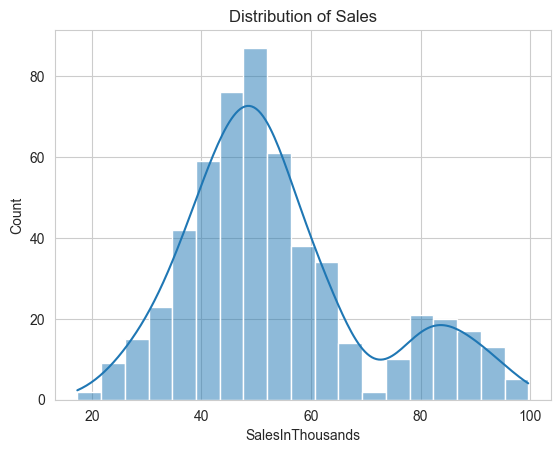

In [88]:
plt.figure()
sns.histplot(df['SalesInThousands'], kde=True)
plt.title("Distribution of Sales")
plt.show()

## Sales by Promotion

C:\Users\Moath\AppData\Local\Temp\ipykernel_9252\1062413901.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Promotion', y='SalesInThousands', data=df, palette='Set2')


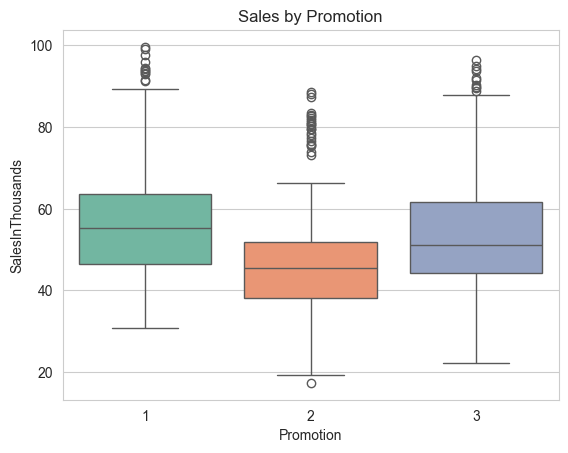

In [89]:
plt.figure()
sns.boxplot(x='Promotion', y='SalesInThousands', data=df, palette='Set2')
plt.title("Sales by Promotion")
plt.show()

## Sales Trend Over Weeks

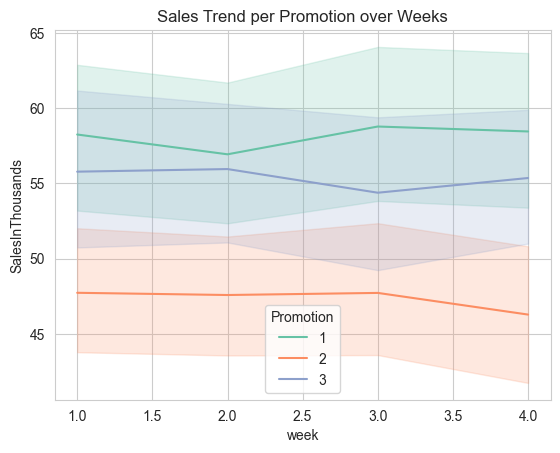

In [90]:
sns.lineplot(x='week', y='SalesInThousands', hue='Promotion', data=df ,palette='Set2')
plt.title("Sales Trend per Promotion over Weeks")
plt.show()

## Promotion by market size

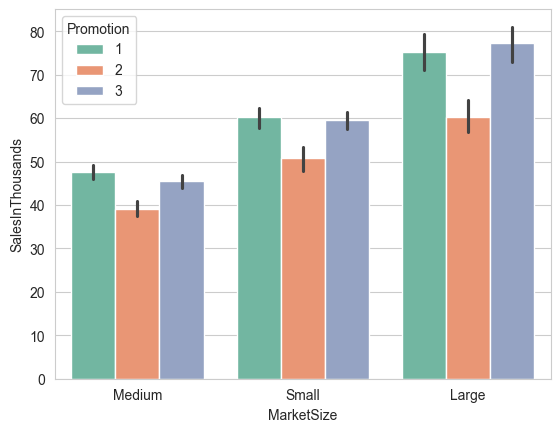

In [91]:
sns.barplot(x='MarketSize', y='SalesInThousands', hue='Promotion', data=df ,palette='Set2')
plt.show()

## Grouped Analysis

In [92]:
df.groupby('Promotion')['SalesInThousands'].mean()

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

In [93]:
df.groupby(['Promotion', 'week'])['SalesInThousands'].mean()

Promotion  week
1          1       58.244419
           2       56.929535
           3       58.774884
           4       58.447209
2          1       47.730213
           2       47.582553
           3       47.722128
           4       46.282766
3          1       55.776170
           2       55.949149
           3       54.377872
           4       55.354681
Name: SalesInThousands, dtype: float64

## Hypothesis Testing (ANOVA)

In [94]:
df_agg = df.groupby(['LocationID', 'Promotion'])['SalesInThousands'].mean().reset_index()

group1 = df_agg[df_agg['Promotion'] == 1]['SalesInThousands']
group2 = df_agg[df_agg['Promotion'] == 2]['SalesInThousands']
group3 = df_agg[df_agg['Promotion'] == 3]['SalesInThousands']


f_stat, p_value = stats.f_oneway(group1, group2, group3)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 5.845791931827379
p-value: 0.0036805468987114263


## Decision 

In [95]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Significant differences exist between promotions")
else:
    print("Fail to reject H0 → No significant difference")

Reject H0 → Significant differences exist between promotions


## Post-Hoc Test (Tukey)

In [96]:
tukey = pairwise_tukeyhsd(
    endog=df['SalesInThousands'],
    groups=df['Promotion'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


## Conclusion and Business Recommendations

### 1. Statistical Findings:

ANOVA demonstrated a statistically significant difference in sales, confirming that the type of promotional campaign truly impacts new product sales.

The Tukey HSD test clearly showed that promotional campaigns 1 and 3 significantly outperformed campaign 2.

Statistics showed no statistically significant difference between campaign 1 and campaign 3, meaning they achieved roughly the same total sales level.

### 2. Business Recommendations:
Since the data did not reveal a clear winner between campaigns 1 and 3, the business decision should be based on the following factors:

Discontinue Campaign 2: It is advisable to completely discontinue campaign 2 due to its poor performance compared to alternatives.

Market Segmentation: Based on the visual data analysis (Boxplot), a hybrid strategy is recommended:

Use campaign 3 in large markets due to its exceptional performance there.

Use campaign 1 in medium and small markets, where it has demonstrated stability and superior performance.